In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import secrets
from statistics import mean

In [42]:
#seed = secrets.randbits(128)
seed1 = 140715127263965253306750513782947248795
seed2 = 285818956044201341035986124735597385543
rng1 = np.random.default_rng(seed1)
rng2 = np.random.default_rng(seed2)

arrival_distribution =  4 * rng1.random()<br>
service_distribution = 6 + 4 * rng1.random()

FREE = 0 <br>
BUSY = 1 <br>
ARRIVAL = 0 <br>
DIPARTURE = i | i = 1, 2, 3, ..., numberOfServers

In [43]:
class Sim:
    def __init__(self, t, numberOfServers=1):
        #simulation variables
        self.t = t
        self.numberOfServers = numberOfServers
        self.tNow = 0
        self.FEL = []#format of FEL: [type of event, time of event, customerId]
        self.FEL_Log = []#logs of the FEL
        self.table = []
        #format fo table:
        '''[customer No.,
            time between arrivals,
            wating time,
            service time,
            time of arrival,
            time of service Begins,
            time of service ends,
            server]'''

        
        #system state
        for i in range(self.numberOfServers):
            setattr(self, f'status{i+1}', 0)
        self.queue = [] 

        
        #Statistical Accumalator
        
        for i in range(self.numberOfServers):
            setattr(self, f'employmentTime{i+1}', 0)   
        self.customerWatingTime = []
        self.totalWatingline = 0 # shows how many customers has stayed in wating line.
        self.totalWatinglineServed = 0 # shows how many customers has stayed in wating line and they service started.
        self.customerCounter = 0
        self.servicedCustomers = 0 #The number of customers who have been serviced. The service may not be finished yet
        self.leftCustomers = 0

    
        #start simulation
        self.controller()

    
    def checkStatus(self):
        for i in range(self.numberOfServers):
            if getattr(self, f'status{i+1}') == 0:
                return True
        return False

    
    def arrival(self, code, time, customerId):
        #specification and timing next arrival and add it to FEL
        self.customerCounter += 1
        timeBetweenArrival = 4 * rng1.random()
        self.FEL.append([0, self.tNow + timeBetweenArrival, self.customerCounter])
        self.table.append(None)
        self.table[self.customerCounter - 1] = [None] * 8
        self.table[self.customerCounter - 1][0], self.table[self.customerCounter - 1][1], self.table[self.customerCounter - 1][4] = self.customerCounter, timeBetweenArrival, self.tNow + timeBetweenArrival
        #free server?
        if self.checkStatus():#free server exist
            #specify service time
            self.servicedCustomers += 1
            serviceTime = 6 + 4 * rng1.random()
            # self.table[self.servicedCustomers - 1][3] = serviceTime
            # self.table[self.servicedCustomers - 1][5] = self.tNow 
            self.table[customerId - 1][3] = serviceTime
            self.table[customerId - 1][5] = self.tNow 
            self.table[customerId - 1][6] = self.tNow + serviceTime
            freeServers = []
            for i in range(self.numberOfServers):
                if getattr(self, f'status{i+1}') == 0:
                    freeServers.append(i+1)
            selectedServer = freeServers[rng2.integers(0,len(freeServers))]
            setattr(self, f'status{selectedServer}', 1)
            self.FEL.append([selectedServer, self.tNow + serviceTime, customerId])
            self.table[customerId - 1][7] = selectedServer
            #self.FEL.append([selectedServer, self.tNow + serviceTime, self.customerCounter])
            #it seens to be the commented line above completely wrong and rather than self.tatalCustomers should write self.servicedCustomers
            if (self.tNow + serviceTime) <= self.t:
                setattr(self, f'employmentTime{selectedServer}', getattr(self, f'employmentTime{selectedServer}') + serviceTime)
            else:
                setattr(self, f'employmentTime{selectedServer}', getattr(self, f'employmentTime{selectedServer}') + self.t - self.tNow)
        else:#free sever dosent available
            self.totalWatingline += 1
            self.queue.append([time, customerId])
    
    
    def departure(self, code, time, customerId):
        self.leftCustomers += 1
        #self.table[customerId - 1][6] = time
        #self.table[customerId - 1][7] = code
        # self.table[self.leftCustomers - 1][6] = time
        # self.table[self.leftCustomers - 1][7] = code
        if len(self.queue) == 0:
            setattr(self, f'status{code}', 0)
        else:
            self.customerWatingTime.append(self.tNow - self.queue[0][0])
            serviceTime = 6 + 4 * rng1.random()
            self.servicedCustomers += 1
            self.totalWatinglineServed += 1
            # self.table[self.servicedCustomers - 1][3] = serviceTime
            # self.table[self.servicedCustomers - 1][5] = self.tNow 
            # self.table[self.servicedCustomers - 1][2] = self.customerWatingTime[-1]
            self.table[self.queue[0][1] - 1][3] = serviceTime
            self.table[self.queue[0][1] - 1][5] = self.tNow 
            self.table[self.queue[0][1] - 1][2] = self.customerWatingTime[-1]
            self.table[self.queue[0][1] - 1][6] = self.tNow + serviceTime
            self.table[self.queue[0][1] - 1][7] = code
            self.FEL.append([code, self.tNow + serviceTime, self.queue.pop(0)[1]])
            if (self.tNow + serviceTime) <= self.t:
                setattr(self, f'employmentTime{code}', getattr(self, f'employmentTime{code}') + serviceTime)
            else:
                setattr(self, f'employmentTime{code}', getattr(self, f'employmentTime{code}') + self.t - self.tNow) 
                
                
    def controller(self):
        #initialization
        # compute frist arrival time
        self.FEL.append([0, 0, 0])
        self.customerCounter += 1
        self.table.append(None)
        self.table[0] = [None] * 8
        self.table[0][0], self.table[0][4] = 1, 0

        
        while True:
            #Determining the imminent event from FEL
            #sorting the FEL
            self.FEL.sort(key=lambda x: x[1])
            self.FEL_Log.append(self.FEL[0])
            code, time, customerId = self.FEL.pop(0)#removing imminent event from FEL
            # update clock to the time of imminent event
            self.tNow = time
            if self.tNow > self.t: break
            #while self.tNow <= self.t:
            if code == 0:# check the code of event
                self.arrival(code, time, customerId)
            else:
                self.departure(code, time, customerId)
                
        #format the results of simulation
        self.table = np.asarray(self.table)
        #self.df = pd.DataFrame(self.table[:self.servicedCustomers, :], columns=[
        self.df = pd.DataFrame(self.table[:, :], columns=[
            'customer No.',
            'time between arrivals',
            'wating time',
            'service time',
            'time of arrival',
            'time of service Begins',
            'time of service ends',
            'server'])  
        self.df = self.df.style.format(precision=14, decimal=".")
        self.df = self.df.hide()

In [44]:
def resutls(simulationsArray, printf=True):
    for i in range(simulationsArray[0].numberOfServers):
        globals()[f'employmentPercent{i+1}'] = []
    customerAverageWatingTime = []
    totalWatingline = []
    totalWatinglineServed = []
    leftCustomers = []
    for simulation in simulationsArray:
        for i in range(simulation.numberOfServers):
            globals()[f'employmentPercent{i+1}'].append(getattr(simulation, f'employmentTime{i+1}') / simulation.t) 
        if len(simulation.customerWatingTime) > 0:
            customerAverageWatingTime.append(sum(simulation.customerWatingTime) / simulation.servicedCustomers) 
        else:
            customerAverageWatingTime.append(0)
        totalWatingline.append(simulation.totalWatingline) 
        totalWatinglineServed.append(simulation.totalWatinglineServed)
        leftCustomers.append(simulation.leftCustomers)
    employmentPercentTotal = []
    for i in range(simulationsArray[0].numberOfServers):
        employmentPercentTotal.append(100*mean(globals()[f'employmentPercent{i+1}']))
        if printf:
            print(f"average employment of server_{i+1}:                                   {100*mean(globals()[f'employmentPercent{i+1}'])} %")
    if printf:
        print(f'average employment of all servers:                                {mean(employmentPercentTotal)}')
        print(f'customer average wating time:                                     {mean(customerAverageWatingTime)}')
        print(f'average persons have stayed in wating line:                       {mean(totalWatingline)}')
        print(f'average persons have stayed in wating line and received service:  {mean(totalWatinglineServed)}')
        print(f'average persons received service complately:                      {mean(leftCustomers)}')
    return mean(employmentPercentTotal), mean(customerAverageWatingTime)

In [45]:
def simulator(t, numberOfServers=1, printf=True, ShowPandasDF=True, numberOfIterations=30, returnSimulations=True):
    simulations = list()
    for i in range(numberOfIterations):
        simulations.append(Sim(t, numberOfServers))
    averageEmployment, customerAverageWatingTime = resutls(simulations, printf)
    if ShowPandasDF:
        for simulation in simulations:
                display(simulation.df)
    if returnSimulations: return simulations
    else: return averageEmployment, customerAverageWatingTime

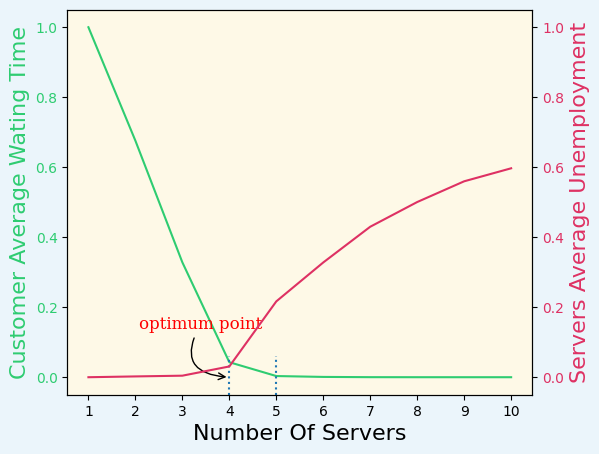

In [46]:
y1 = []
y2 = []
x = []
maxCustomerAverageWatingTime = 0
for i in range(1,11):
    averageEmployment, customerAverageWatingTime = simulator(t=480, numberOfServers=i, printf=False, ShowPandasDF=False, numberOfIterations=30, returnSimulations=False)
    x.append(i)
    if i == 1:
        maxCustomerAverageWatingTime =  customerAverageWatingTime
    y1.append(customerAverageWatingTime / maxCustomerAverageWatingTime)
    y2.append(1 - averageEmployment / 100)
fig, ax1 = plt.subplots(figsize=(6, 5))
fig.set_facecolor('#EBF5FB')
ax1.set_facecolor('#FEF9E7')
ax1.set_xticks(np.arange(0, 11, step=1))
ax1.plot(x, y1, color='#2ECC71')
ax1.set_ylim(-0.05,1.05)
ax2 = ax1.twinx()
ax2.set_ylim(-0.05,1.05)
ax2.plot(x, y2, color='#DE3163')
for label in ax1.get_yticklabels():
    label.set_color('#2ECC71')
for label in ax2.get_yticklabels():
    label.set_color('#DE3163')
ax1.axvline(4, ymax=.1,linestyle=':')
ax1.axvline(5, ymax=.1,linestyle=':')
ax1.set_ylabel('Customer Average Wating Time', fontsize='16', color='#2ECC71')
ax1.set_xlabel('Number Of Servers', fontsize='16', color='black')
ax2.set_ylabel('Servers Average Unemployment', fontsize='16', color='#DE3163')
ax1.annotate('optimum point', xy=(4, +0), fontsize='12', color='red', family="serif", xycoords='data', xytext=(-65, 35), textcoords='offset points', arrowprops=dict(arrowstyle='->', connectionstyle='arc3, rad=.8'))
fig.savefig('plot.png',dpi=750)

In [47]:
simulator(480, numberOfServers=4, printf=True, ShowPandasDF=False, numberOfIterations=30, returnSimulations=False)

average employment of server_1:                                   96.68340292846015 %
average employment of server_2:                                   96.4902829471702 %
average employment of server_3:                                   96.65151018696957 %
average employment of server_4:                                   96.75732024371368 %
average employment of all servers:                                96.6456290765784
customer average wating time:                                     7.681602779911322
average persons have stayed in wating line:                       205.9
average persons have stayed in wating line and received service:  201
average persons received service complately:                      230.1


(96.6456290765784, 7.681602779911322)

In [48]:
simulator(480, numberOfServers=5, printf=True, ShowPandasDF=False, numberOfIterations=30, returnSimulations=False)

average employment of server_1:                                   77.98931117420894 %
average employment of server_2:                                   77.82943138295566 %
average employment of server_3:                                   77.9385993834178 %
average employment of server_4:                                   78.05200893772167 %
average employment of server_5:                                   79.5204420133867 %
average employment of all servers:                                78.26595857833816
customer average wating time:                                     0.5165667764944321
average persons have stayed in wating line:                       66.23333333333333
average persons have stayed in wating line and received service:  65.8
average persons received service complately:                      233.46666666666667


(78.26595857833816, 0.5165667764944321)

In [49]:
simulator(480, numberOfServers=4, printf=False, ShowPandasDF=True, numberOfIterations=1, returnSimulations=True)

customer No.,time between arrivals,wating time,service time,time of arrival,time of service Begins,time of service ends,server
1,None,None,None,0,None,None,None
2,1.49292884914938,None,9.34247695481373,1.49292884914938,1.49292884914938,10.83540580396311,3
3,3.11436202306853,None,6.74057128926081,4.60729087221791,4.60729087221791,11.34786216147872,4
4,2.58618563085328,None,8.45265775348212,7.19347650307119,7.19347650307119,15.64613425655331,2
5,1.40646266903162,0.53757358613756,6.97636186776488,8.59993917210281,9.13751275824037,16.11387462600525,1
6,1.29838074366735,0.93708588819295,6.54711940416881,9.89831991577016,10.83540580396311,17.38252520813192,3
7,2.06013806189612,None,8.35374615627807,11.95845797766628,11.95845797766628,20.31220413394434,4
8,0.88178004117829,2.80589623770874,6.94292979685725,12.84023801884457,15.64613425655331,22.58906405341056,2
9,0.72181723269743,2.55181937446325,6.27123413858656,13.56205525154200,16.11387462600525,22.38510876459181,1
10,3.55606858163551,0.26440137495441,7.81287022960183,17.11812383317751,17.38252520813192,25.19539543773375,3


In [50]:
simulator(480, numberOfServers=5, printf=False, ShowPandasDF=True, numberOfIterations=1, returnSimulations=True)

customer No.,time between arrivals,wating time,service time,time of arrival,time of service Begins,time of service ends,server
1,None,None,None,0,None,None,None
2,1.82267256617180,None,8.10125179060494,1.82267256617180,1.82267256617180,9.92392435677674,5
3,3.71114678292606,None,8.99382019254225,5.53381934909785,5.53381934909785,14.52763954164010,1
4,0.82180972645597,None,8.05615706816053,6.35562907555382,6.35562907555382,14.41178614371435,4
5,2.47126602053796,None,6.12451135589814,8.82689509609178,8.82689509609178,14.95140645198992,2
6,2.66353798049991,None,9.28355508392401,11.49043307659169,11.49043307659169,20.77398816051570,5
7,1.55018269437780,None,9.23060161563130,13.04061577096948,13.04061577096948,22.27121738660079,3
8,1.19449004378097,0.17668032896390,6.59305618305405,14.23510581475045,14.41178614371435,21.00484232676840,4
9,2.08468171659111,None,7.24866514124122,16.31978753134156,16.31978753134156,23.56845267258278,2
10,3.72929511776760,None,7.15952439994330,20.04908264910916,20.04908264910916,27.20860704905247,1


## for better output use jupyter-notebook in webbrowser (vscode cant show scrollable charts correctly)

# how to access FEL_Log
```python
simulator(t, numberOfServers, printf,  ShowPandasDF, numberOfIterations)[i].FEL_Log
```
- i = 0, 1, 2, 3, ..., numberOfIterations -1<br>
-  t = desired<br>
- numberOfServers = desired<br>
- printf = False or True<br>
- showPandasDF = False or True<br>
- numberOfIterations= desired but recommended greater then 29<br>
### example
```python
simulation = simulator(480, 5, False, False)
simulation[i].FEL_Log
```